# Exploratory Data Analysis (EDA)

This notebook explores the medical transcription dataset used in this project.

The goal is to understand the structure of the data before building the NLP classification model.

We aim to predict the **medical specialty** based on clinical transcription notes.

## Goals of the Exploratory Analysis

Before building any machine learning model, it is important to understand the dataset.

In this exploratory analysis we will:

- Inspect the structure of the dataset
- Identify the main columns
- Check for missing values
- Explore the distribution of medical specialties
- Analyze the length of the clinical notes

These steps help ensure that the data is clean and suitable for NLP modeling.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In this step we load the dataset that contains medical transcription notes.

Each record represents a clinical note and its corresponding medical specialty.

Key columns expected in the dataset:

- **transcription** → the clinical text
- **medical_specialty** → the label we want to predict

Understanding the structure of the dataset is the first step before performing any data analysis or preprocessing.

In [6]:
df = pd.read_csv("../data/medical_transcriptions.csv")
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


## Dataset Size

Before performing deeper analysis, we first inspect the size of the dataset.

Understanding the number of rows and columns helps us estimate the amount of data available for training machine learning models.

In [7]:
df.shape

(4999, 6)

### Dataset Overview

The dataset contains **4,999 medical transcription samples** and **6 columns** describing each record.

This amount of data is sufficient to build an initial NLP classification model for predicting medical specialties.

## Dataset Columns

Now we inspect the columns available in the dataset.

Understanding the columns helps identify which features are useful for the NLP classification task.}

In [8]:
df.columns

Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')

### Dataset Columns

The dataset contains the following columns:

- **Unnamed: 0** → index column from the original dataset
- **description** → short description of the medical case
- **medical_specialty** → medical specialty associated with the case
- **sample_name** → name of the transcription sample
- **transcription** → full clinical transcription text
- **keywords** → keywords related to the case

For this NLP project, the most relevant columns are:

- **transcription** → input text
- **medical_specialty** → target label

## Missing Values Analysis

Before training a machine learning model, it is important to check if the dataset contains missing values.

Missing values may cause issues during model training or reduce model performance.

In this step we inspect how many missing values exist in each column.

In [9]:
df.isnull().sum()

Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

### Missing Values Summary

The dataset contains some missing values in specific columns:

- **transcription** → 33 missing values
- **keywords** → 1068 missing values

Since the NLP model relies on the transcription text, rows with missing **transcription** values will likely need to be removed during preprocessing.

The **medical_specialty** column contains no missing values, which is ideal since it represents the target label for the classification task.

## Medical Specialty Distribution

In this step we analyze the distribution of medical specialties in the dataset.

Understanding how many samples exist for each specialty is important for machine learning tasks.

If some classes appear much more frequently than others, the dataset may be imbalanced, which can negatively affect model performance.

In [10]:
df["medical_specialty"].value_counts()

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

### Class Distribution

The dataset contains multiple medical specialties with varying numbers of samples.

Some specialties appear much more frequently than others. For example:

- Surgery has over **1000 samples**
- Several specialties contain **fewer than 20 samples**

This indicates that the dataset is **imbalanced**, which may impact model performance.

Handling class imbalance may be considered during later stages of the project.

## Visualizing the Distribution of Medical Specialties

To better understand the class imbalance in the dataset, we visualize the distribution of the most frequent medical specialties.

This helps identify which specialties dominate the dataset and which ones have fewer samples.

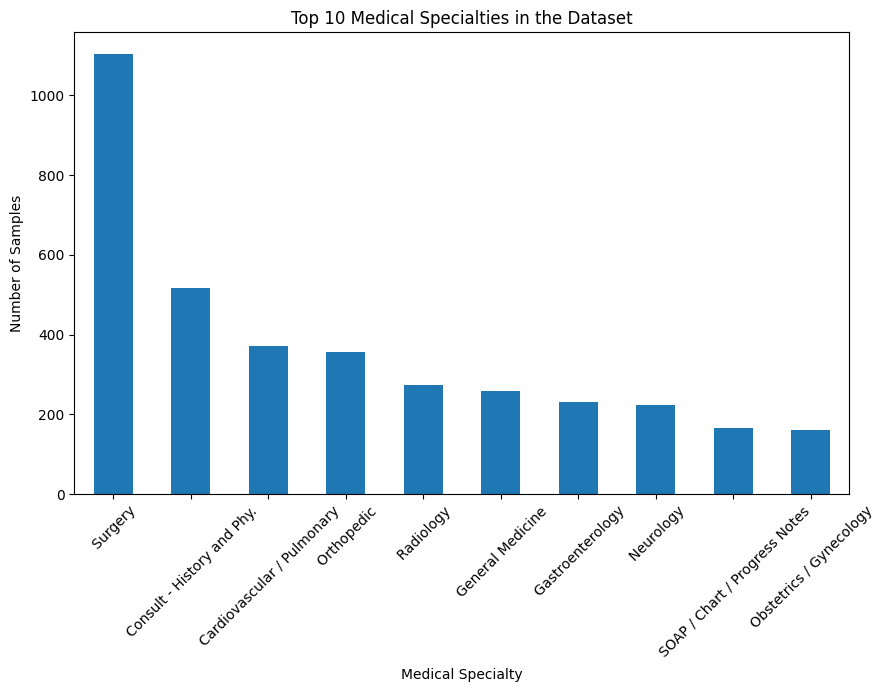

In [11]:
plt.figure(figsize=(10,6))

df["medical_specialty"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Medical Specialties in the Dataset")
plt.xlabel("Medical Specialty")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.show()

### Interpretation of the Class Distribution

The visualization shows that some medical specialties appear much more frequently than others.

For example, **Surgery** is the most represented specialty in the dataset, followed by categories such as **Consult - History and Physical**, **Cardiovascular / Pulmonary**, and **Orthopedic**.

This confirms that the dataset is **imbalanced**, as some specialties contain many more samples than others.

Class imbalance can influence machine learning models, since models may learn dominant classes more easily than minority classes.

## Clinical Note Length Analysis

In natural language processing tasks, the length of the text can influence model performance.

Some clinical notes may be very short, while others may contain long detailed descriptions.

In this step we analyze the distribution of transcription lengths to better understand the structure of the text data.

In [12]:
df["text_length"] = df["transcription"].astype(str).apply(len)

df["text_length"].head()

0    1331
1    2431
2    4422
3     495
4    1618
Name: text_length, dtype: int64

In [13]:
df["text_length"].describe()

count     4999.000000
mean      3032.184837
std       2002.772490
min          3.000000
25%       1590.500000
50%       2659.000000
75%       3995.000000
max      18425.000000
Name: text_length, dtype: float64

### Text Length Statistics

The analysis of transcription lengths shows that clinical notes vary significantly in size.

Key observations:

- The average transcription length is around **3000 characters**
- Some notes are extremely short
- Some notes are very long, exceeding **18,000 characters**

This variability is common in clinical text and may influence the choice of NLP preprocessing techniques.

## Distribution of Clinical Note Length

To better understand how transcription sizes vary, we visualize the distribution of clinical note lengths.

This helps identify whether most notes are short, medium, or long, and whether extreme values exist in the dataset.

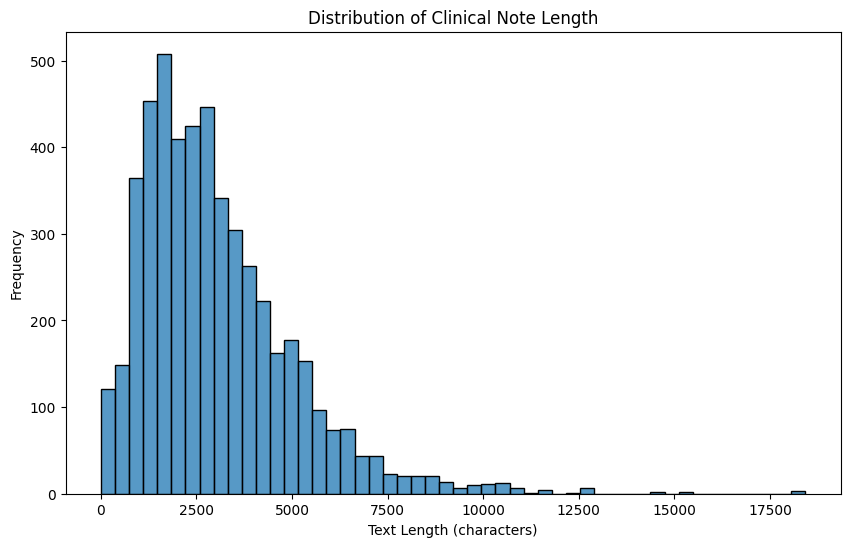

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df["text_length"], bins=50)

plt.title("Distribution of Clinical Note Length")
plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")

plt.show()

## EDA Summary

From the exploratory analysis of the medical transcription dataset, several important observations were identified:

- The dataset contains **4,999 medical transcription samples** across multiple medical specialties.
- The dataset shows **class imbalance**, with some specialties having significantly more samples than others.
- A small number of records contain **missing transcription values**, which will need to be handled during preprocessing.
- Clinical notes vary significantly in length, with an average of around **3000 characters** and some very long records.

These insights will guide the next steps of the project, including data cleaning, text preprocessing, and feature extraction for the NLP classification model.

In [15]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/user/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [17]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [18]:
from src.preprocessing import clean_text

## Testing the Text Cleaning Function

Before applying preprocessing to the entire dataset, we test the `clean_text` function on a single clinical note.

This step helps verify that the preprocessing pipeline works correctly.

The function performs several operations:

- Converts text to lowercase
- Removes punctuation and numbers
- Splits the text into tokens
- Removes common English stopwords

Comparing the original text with the cleaned version helps ensure that the preprocessing behaves as expected.

In [19]:
example_text = df["transcription"].iloc[0]

print("Original text:")
print(example_text)

print("\nCleaned text:")
print(clean_text(example_text))

Original text:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal sprays.  She does have asthma but doest not require daily medication for this and does not think it is flaring up.,MEDICATIONS: , Her only medication currently is Ortho Tri-Cyclen and the Allegra.,ALLERGIES: , She has no known medicine allergies.,OBJECTIVE:,Vitals:  Weight was 130 pounds and blood pressure 124/78.,HEENT:  Her throat was mildly erythematous without exudate.  Nasal mucosa was erythematous and swollen.  Only clear drainage was seen.  TMs were clear.,Neck:  Supple withou

### Result of the Preprocessing Test

The comparison between the original transcription and the cleaned text demonstrates that the preprocessing function is working correctly.

Key observations:

- The text was converted to lowercase
- Punctuation and special characters were removed
- Common stopwords were filtered out
- The remaining words represent the most meaningful terms in the clinical note

This cleaned version of the text is more suitable for machine learning models, since it reduces noise and focuses on the most relevant medical terms.

## Applying Text Preprocessing to the Dataset

After validating the `clean_text` function on a single example, we now apply the preprocessing pipeline to the entire dataset.

This step transforms the raw clinical transcriptions into cleaned text that can be used for machine learning models.

A new column called **clean_text** will be created to store the processed version of each transcription, while preserving the original text for reference.

In [20]:
df["clean_text"] = df["transcription"].astype(str).apply(clean_text)

df[["transcription", "clean_text"]].head()

,transcription,clean_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective yearold white female presents compl...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history difficulty climbing stair...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history present illness seen abc today pleasan...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",mmode left atrial enlargement left atrial diam...
4,1. The left ventricular cavity size and wall ...,left ventricular cavity size wall thickness ap...


### Preprocessed Text Column

The preprocessing pipeline was applied to all clinical transcriptions in the dataset.

A new column called **clean_text** was created to store the processed version of each transcription.

This cleaned text removes noise such as punctuation, numbers, and common stopwords, making the data more suitable for machine learning models.

Keeping both the original and cleaned text allows us to preserve the raw data while using the processed version for NLP modeling.

## Handling Invalid or Empty Transcriptions

Before training a machine learning model, it is important to ensure that the dataset does not contain invalid or empty text entries.

Very short or empty transcriptions may not provide useful information for NLP models and can negatively affect model performance.

In this step we identify and remove transcriptions that are empty or extremely short after preprocessing.

In [22]:
df["clean_word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

df["clean_word_count"].describe()

count    4999.000000
mean      261.525705
std       172.819039
min         1.000000
25%       137.000000
50%       229.000000
75%       342.000000
max      1628.000000
Name: clean_word_count, dtype: float64

### Word Count Analysis

The cleaned clinical transcriptions contain varying numbers of words.

Key observations:

- The average transcription contains approximately **260 words**
- The shortest entries contain only **1 word**
- Some clinical notes are very long, exceeding **1600 words**

Very short entries may not provide useful information for machine learning models and may be removed during preprocessing.

## Removing Extremely Short Transcriptions

Very short clinical notes may not contain enough information for a machine learning model to learn meaningful patterns.

To improve data quality, we remove transcriptions with very few words after preprocessing.

In this project, we will remove entries containing fewer than **5 words**, since such texts are unlikely to provide useful clinical context.

In [23]:
df = df[df["clean_word_count"] >= 5]

df.shape

(4943, 9)

### Dataset After Filtering Short Transcriptions

After removing extremely short transcriptions, the dataset now contains **4,943 valid clinical notes**.

A small number of entries were removed because they contained fewer than 5 words after preprocessing.

Filtering these records helps improve data quality and ensures that the machine learning model is trained on meaningful clinical text.

## Feature Extraction with TF-IDF

Machine learning models cannot directly process raw text. Therefore, the textual data must be converted into numerical representations.

In this project we use **TF-IDF (Term Frequency - Inverse Document Frequency)** to transform the cleaned clinical notes into numerical feature vectors.

TF-IDF measures the importance of each word within a document relative to the entire dataset.

Words that appear frequently in a specific document but not across many documents receive higher weights, making them more useful for classification tasks.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

### Creating the TF-IDF Feature Matrix

After cleaning the clinical text, the next step is to convert the text data into numerical features.

Using the **TF-IDF vectorizer**, we transform the cleaned clinical notes into a matrix where:

- Each row represents a clinical transcription
- Each column represents a word (feature)
- Each value represents the importance of that word in the document

This numerical representation allows machine learning algorithms to process and learn patterns from the text data.

In [27]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

X.shape

(4943, 5000)

### TF-IDF Feature Matrix

The TF-IDF vectorization process converted the cleaned clinical notes into a numerical feature matrix.

The resulting matrix has the following shape:

- **4,943 rows** representing clinical transcriptions
- **5,000 columns** representing the most important words in the dataset

This matrix will be used as input features for training the machine learning classification model.

## Defining the Target Variable

In a supervised machine learning task, the model learns to predict a target variable based on input features.

In this project, the target variable is **medical_specialty**, which represents the medical specialty associated with each clinical transcription.

The model will learn patterns in the clinical text in order to classify each note into its corresponding medical specialty.

In [28]:
y = df["medical_specialty"]

y.head()

0           Allergy / Immunology
1                     Bariatrics
2                     Bariatrics
3     Cardiovascular / Pulmonary
4     Cardiovascular / Pulmonary
Name: medical_specialty, dtype: object

## Train-Test Split

To evaluate the performance of a machine learning model, it is important to separate the dataset into training and testing sets.

The **training set** is used to train the model and learn patterns from the data.

The **testing set** is used to evaluate how well the model generalizes to unseen data.

In this project, we will use **80% of the data for training** and **20% for testing**.

In [31]:
from sklearn.model_selection import train_test_split

### Splitting the Dataset

To train and evaluate the classification model, we split the dataset into training and testing sets.

The training set will be used by the model to learn patterns from the clinical text, while the testing set will be used to evaluate how well the model performs on unseen data.

We will use **80% of the data for training** and **20% for testing**.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((3954, 5000), (989, 5000))

### Training and Testing Sets

After splitting the dataset:

- **3,954 samples** were used for training
- **989 samples** were used for testing

Each sample is represented by **5,000 TF-IDF features** extracted from the clinical text.

The training set will be used to train the classification model, while the testing set will be used to evaluate its performance.

## Training the Classification Model

After preparing the dataset and extracting TF-IDF features, we can now train a machine learning model to classify clinical transcriptions by medical specialty.

In this project, we will start with **Logistic Regression**, a commonly used algorithm for text classification tasks.

Logistic Regression works well with high-dimensional text data and provides a strong baseline model for NLP classification problems.

In [33]:
from sklearn.linear_model import LogisticRegression

### Initializing the Logistic Regression Model

Next, we create the Logistic Regression model that will be used to classify clinical transcriptions.

This model will learn patterns in the TF-IDF features extracted from the clinical text and attempt to predict the corresponding medical specialty.

In [34]:
model = LogisticRegression(max_iter=1000)

### Training the Model

After initializing the Logistic Regression model, the next step is to train it using the training dataset.

During training, the model learns relationships between the TF-IDF features extracted from the clinical text and the corresponding medical specialties.

The trained model will then be used to make predictions on unseen data from the testing set.

In [35]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Evaluation

After training the classification model, the next step is to evaluate its performance on the testing dataset.

The testing set contains data that the model has not seen during training. This allows us to measure how well the model generalizes to new clinical transcriptions.

We will generate predictions for the testing data and compare them with the true labels.

In [36]:
y_pred = model.predict(X_test)

y_pred[:10]

array([' Surgery', ' Surgery', ' Surgery', ' Surgery', ' Surgery',
       ' Consult - History and Phy.', ' Surgery',
       ' Psychiatry / Psychology', ' Orthopedic', ' General Medicine'],
      dtype=object)

### Generating Predictions

After training the Logistic Regression model, we generate predictions for the testing dataset.

The model predicts the medical specialty for each clinical transcription based on the learned patterns from the training data.

These predictions will be compared with the true labels to evaluate the model's performance.

### Accuracy Score

To evaluate the performance of the classification model, we compute the **accuracy score**.

Accuracy measures the proportion of correct predictions made by the model compared to the total number of predictions.

It provides a simple indication of how well the model performs on the testing dataset.

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.26693629929221435

### Model Accuracy

The Logistic Regression model achieved an accuracy of approximately **26.7%** on the testing dataset.

Although this value may appear low, the classification task involves a large number of medical specialties, making it a challenging multi-class classification problem.

This baseline model demonstrates that the TF-IDF features capture meaningful patterns from the clinical text.

### Classification Report

Accuracy alone does not provide a complete understanding of model performance.

To obtain a more detailed evaluation, we compute the **classification report**, which includes:

- **Precision**: how many predicted labels were correct
- **Recall**: how many actual labels were correctly identified
- **F1-score**: harmonic mean of precision and recall

These metrics provide deeper insights into how the model performs across different medical specialties.

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                precision    recall  f1-score   support

          Allergy / Immunology       0.00      0.00      0.00         1
                    Bariatrics       0.00      0.00      0.00         5
    Cardiovascular / Pulmonary       0.21      0.22      0.21        79
    Consult - History and Phy.       0.29      0.57      0.39       106
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         5
                     Dentistry       0.00      0.00      0.00         6
                   Dermatology       0.00      0.00      0.00         4
          Diets and Nutritions       0.00      0.00      0.00         3
             Discharge Summary       0.20      0.08      0.11        26
          ENT - Otolaryngology       0.33      0.04      0.08        23
        Emergency Room Reports       0.00      0.00      0.00        14
                 Endocrinology       0.00      0.00      0.00         2
              Gastroenterology       0.00      0.00      0.00  

/home/user/PycharmProjects/medical-diagnosis-nlp/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/PycharmProjects/medical-diagnosis-nlp/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/PycharmProjects/medical-diagnosis-nlp/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

### Model Performance Analysis

The classification report reveals that the model performs better on medical specialties with a larger number of training examples.

For example, categories such as **Surgery**, **Consult - History and Physical**, and **Radiology** achieved higher scores compared to smaller classes.

Some specialties have very few samples in the dataset, which makes it difficult for the model to learn reliable patterns. This results in lower performance for those classes.

This behavior is expected in datasets with significant class imbalance and a large number of categories.